# Karma visualization notebook

This notebook analyzes the canonical LLM-scored relationship file, `../csvs/karma_edges_v3.csv`, produced in `llm.ipynb`.

The notebook has two roles:

1. **Website-ready figures first**: figures that are used directly on the project website, or are intended to be exported there.
2. **Exploratory and iteration figures later**: plots that helped us understand the data, test visual encodings, or decide what not to put on the website.

This separation keeps the final story easy to audit while preserving the development process behind it.

In [27]:
from collections import Counter
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import networkx as nx
import numpy as np
import pandas as pd


## Load and validate data

We read the final karma edge list, coerce scores to numeric values, drop invalid rows if any remain, and keep only edges where both endpoints still exist in the cleaned character table. The directed graph `DG` is the shared object used by all plots below.

In [28]:
from pathlib import Path

# BASE_DIR = the repo root. Resolves correctly whether Jupyter is launched from the
# repo root, from Karma/, or from one level above the repo.
BASE_DIR = Path.cwd()
if not (BASE_DIR / 'csvs').exists() and (BASE_DIR / 'CompSciProject' / 'csvs').exists():
    BASE_DIR = BASE_DIR / 'CompSciProject'
if not (BASE_DIR / 'csvs').exists() and (BASE_DIR.parent / 'csvs').exists():
    BASE_DIR = BASE_DIR.parent

karma = pd.read_csv(BASE_DIR / 'csvs' / 'karma_edges_v3.csv')
karma['karma_score'] = pd.to_numeric(karma['karma_score'], errors='coerce')
karma = karma.dropna(subset=['karma_score'])

df = pd.read_csv(BASE_DIR / 'csvs' / 'characters_enriched_v3.csv').fillna('')
valid_ids = set(df['ID'])
name_by_id = dict(zip(df['ID'], df['name']))
primary_house = {
    row['ID']: (row['allegiance'].split(';')[0].strip() if row['allegiance'] else '')
    for _, row in df.iterrows()
}

before = len(karma)
karma = karma[karma['source_id'].isin(valid_ids) & karma['target_id'].isin(valid_ids)]
print(f'Karma edges: {len(karma):,} (dropped {before - len(karma)} with unknown source/target)')

DG = nx.DiGraph()
for _, row in karma.iterrows():
    DG.add_edge(row['source_id'], row['target_id'], score=float(row['karma_score']))
for n in DG.nodes():
    DG.nodes[n]['house'] = primary_house.get(n, '')

print(f'Directed graph: {DG.number_of_nodes()} nodes, {DG.number_of_edges()} edges')


Karma edges: 5,159 (dropped 0 with unknown source/target)
Directed graph: 1307 nodes, 5159 edges


In [29]:
# House palette — matches the website UI (script.js → houseColors).
# Karma edge colors below also match the website's getScoreColor: red ≤3 / green ≥7.
HOUSE_COLOR = {
    # Canonical website colors
    'House_Stark':          '#4169a8',
    'House_Lannister':      '#b6292d',
    'House_Targaryen':      '#c65b36',
    'House_Baratheon':      '#c99a2e',
    'House_Greyjoy':        '#657a83',
    'House_Tyrell':         '#3f8d5a',
    'House_Martell':        '#c96f2d',
    'House_Velaryon':       '#247f7a',
    'House_Frey':           '#8269a8',
    "Night's_Watch":        '#272d33',
    'Kingsguard':           '#d8c781',
    # Coordinated extras (not in website but matching its earthy/gold/parchment palette)
    'House_Tully':          '#3a5e8d',  # river blue (darker Stark family)
    'House_Arryn':          '#88aacc',  # falcon sky
    'House_Bolton':         '#a85060',  # flayed pink
    'House_Karstark':       '#4a4a4a',
    'House_Mormont':        '#3e553a',
    'House_Manderly':       '#4a7a78',
    'House_Umber':          '#4a3a30',
    'House_Glover':         '#5a4530',
    'House_Reed':           '#4a5a3a',
    'House_Royce':          '#a87c4a',
    'House_Tarth':          '#5a93bd',
    'House_Westerling':     '#a8a8a8',
    'House_Marbrand':       '#b85838',
    'House_Crakehall':      '#403838',
    'House_Swyft':          '#9a8857',
    'House_Clegane':        '#6a4232',
    'House_Selmy':          '#c2b87a',
    'House_Hightower':      '#d8c47a',
    'House_Redwyne':        '#7a3a3a',
    'House_Tarly':          '#7a6a3a',
    'House_Florent':        '#a55a8b',
    'House_Caron':          '#7a8a4a',
    'House_Merryweather':   '#a07c4a',
    'House_Estermont':      '#3e6644',
    'House_Penrose':        '#cdc6b0',
    'House_Massey':         '#5a3a72',
    'House_Celtigar':       '#9a4040',
    'House_Strong':         '#8a7050',
    'House_Chelsted':       '#604a4a',
    'House_Dayne':          '#bda6c7',
    'House_Yronwood':       '#9a663a',
    'House_Fowler':         '#a07a55',
    'House_Manwoody':       '#605552',
    'House_Blackfyre':      '#3a3a4f',
    'House_Connington':     '#c8826a',
    'House_Peake':          '#806060',
    'House_Rowan':          '#8a9a60',
    'Citadel':              '#7a6038',
    "R'hllor":              '#b85020',
    'Faith_of_the_Seven':   '#d8c787',
    'Brave_Companions':     '#5a3a4a',
    'Second_Sons':          '#6a4a3a',
    'Iron_Bank':            '#7a6a3a',
    'Kettleblack':          '#5a4040',
    'Blacks':               '#1f1f1f',
    'Mance_Rayder':         '#6e6e6e',
    'Order':                '#444444',
    'Sellsword':            '#777777',
    'Outlaw':               '#222222',
}

# Edge / fallback / "no house" colors — also website-aligned
KARMA_RED   = '#b6292d'   # website enemy
KARMA_GREEN = '#3f8d5a'   # website friend
NEUTRAL     = '#8c8674'   # parchment-muted neutral (matches website --muted)
OTHER_COLOR = '#7b746c'   # website "Other"

_FALLBACK_PALETTE = plt.cm.tab20b.colors

def house_color_for(h: str):
    """Website-aligned color for a house ID; deterministic fallback for unknown houses."""
    if not h:
        return OTHER_COLOR
    if h in HOUSE_COLOR:
        return HOUSE_COLOR[h]
    idx = (sum(ord(c) for c in h) * 7) % len(_FALLBACK_PALETTE)
    return _FALLBACK_PALETTE[idx]


---

# Website-ready figures

These are the figures that belong closest to the website story. The website currently uses the score distribution and the ten character ego networks. The force-directed conflict graph is kept here as a website-candidate figure because the website has a placeholder for a conflict graph; if we do not use it, it can move to the exploratory section later.

## Website figure 1 - Karma score distribution

This is the headline distribution used on the website. It shows the full 1-10 karma scale, marks the mean score, and highlights the main narrative point: strong negative relationships are more common than equally strong positive ones.

Website output: `website/figures/karma_distribution/karma_dist.png`.


In [ ]:
from matplotlib.colors import LinearSegmentedColormap

FIG_DIR = BASE_DIR / 'website' / 'figures'
KARMA_DIST_DIR = FIG_DIR / 'karma_distribution'
KARMA_DIST_DIR.mkdir(parents=True, exist_ok=True)

# Headline stats for the Karma chapter copy and plot annotation.
scores = karma['karma_score'].dropna().astype(int)
n = len(scores)
mean_k = scores.mean()
median_k = scores.median()
low_n = (scores <= 2).sum()
high_n = (scores >= 9).sum()
low_share = low_n / n * 100
high_share = high_n / n * 100
ratio = low_n / high_n if high_n else float('inf')
mid_share = (scores == 5).sum() / n * 100

print(f"Mean karma:                  {mean_k:.2f} / 10")
print(f"Median karma:                {median_k:.1f}")
print(f"Total scored relationships:  {n:,}")
print(f"Score 1-2:                   {low_n:,} ({low_share:.1f}%)")
print(f"Score 9-10:                  {high_n:,} ({high_share:.1f}%)")
print(f"Low/high extreme ratio:      {ratio:.1f}x")
print(f"Neutral score 5:             {mid_share:.1f}%")

# Site palette.
BG = '#0c0d11'
INK = '#ece5d1'
INK_SOFT = '#c8c1ad'
MUTED = '#8c8674'
LINE = '#3d3e48'
GOLD = '#c9a661'
GOLD_BR = '#e3c382'
CRIMSON = '#8b1d22'
CRIMSON_BR = '#b3262d'

counts = np.array([(scores == s).sum() for s in range(1, 11)])
centers = np.arange(1, 11)

cmap = LinearSegmentedColormap.from_list(
    'karma_div',
    [CRIMSON_BR, CRIMSON, '#6b3a3c', MUTED, '#7a6a3f', GOLD, GOLD_BR],
)
colors = cmap(np.linspace(0, 1, len(centers)))

fig, ax = plt.subplots(figsize=(11, 6), facecolor=BG)
ax.set_facecolor(BG)
fig.subplots_adjust(top=0.82, left=0.09, right=0.97, bottom=0.13)

ax.bar(centers, counts, width=0.82, color=colors,
       edgecolor=BG, linewidth=1.5, zorder=3)

ymax = counts.max()

ax.axvline(mean_k, color=GOLD_BR, linestyle='--', linewidth=1.6,
           alpha=0.95, zorder=4)
ax.text(mean_k + 0.12, ymax * 0.96, f'mean = {mean_k:.2f}',
        color=GOLD_BR, fontsize=11, ha='left', va='top', fontstyle='italic')

ax.text(1.5, ymax * 0.55, 'strong\ncontempt', color=CRIMSON_BR,
        fontsize=11, ha='center', va='center',
        fontstyle='italic', fontweight='bold')
ax.text(5, ymax * 1.02, "the model's hedge", color=INK_SOFT,
        fontsize=10, ha='center', va='bottom', fontstyle='italic')
ax.text(9.5, ymax * 0.55, 'rare\nloyalty', color=GOLD_BR,
        fontsize=11, ha='center', va='center',
        fontstyle='italic', fontweight='bold')

for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
for spine in ('left', 'bottom'):
    ax.spines[spine].set_color(LINE)

ax.tick_params(colors=INK_SOFT, length=4)
ax.set_xticks(range(1, 11))
ax.set_xlim(0.3, 10.7)
ax.set_ylim(0, ymax * 1.18)
ax.set_xlabel('Karma score (1 = enemy · 10 = devoted)',
              color=INK_SOFT, fontsize=12, labelpad=10)
ax.set_ylabel('Number of relationships',
              color=INK_SOFT, fontsize=12, labelpad=10)

fig.text(0.09, 0.94, 'Strong feelings tilt hostile',
         color=INK, fontsize=17, ha='left', va='top', fontweight='bold')
fig.text(0.09, 0.87,
         f'Among {n:,} LLM-scored character relationships, '
         f'{ratio:.1f}× more land in the 1-2 range than in the 9-10 range.',
         color=INK_SOFT, fontsize=11.5, ha='left', va='top')

out = KARMA_DIST_DIR / 'karma_dist.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f'Saved {out.relative_to(BASE_DIR)}')
plt.show()

## Website figure 2 - Ego networks for 10 major characters

Each panel shows one character's outgoing karma: how that character is scored toward the people around them. Red edges mark enemy scores, grey edges neutral ties, and green edges friendly ties. Nodes are grouped by the target character's house.

Website outputs: `website/figures/ego_networks/*.png`.

The exported PNGs use the same dark website palette as the live page (`#0c0d11` background with light labels and a dark legend).


Saved website/figures/ego_networks/tyrion_lannister.png


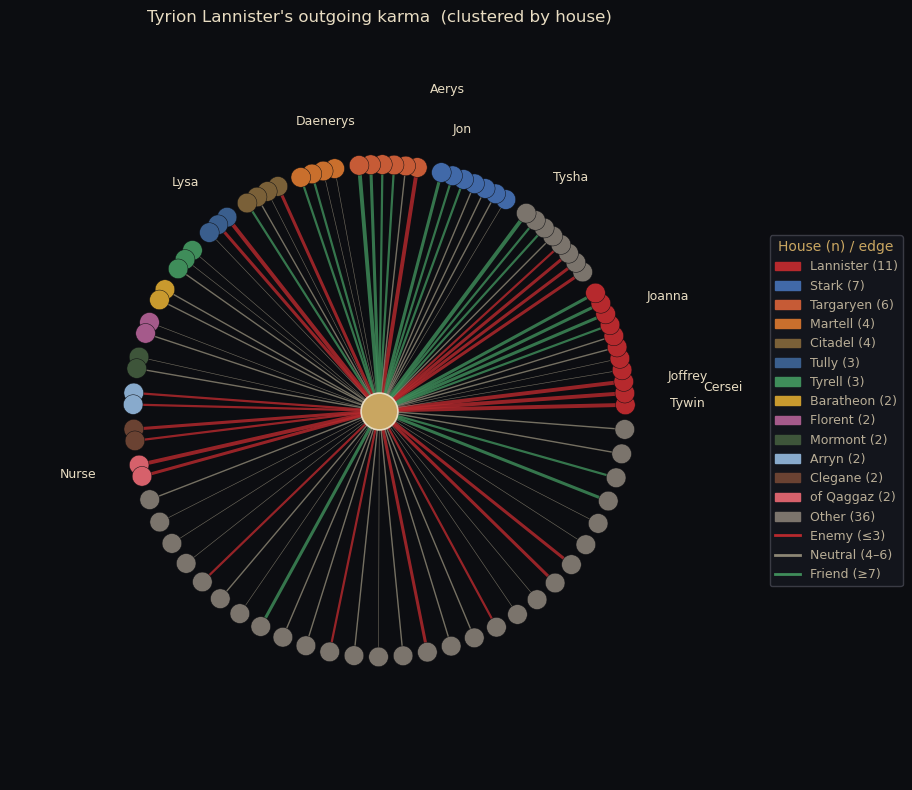

Saved website/figures/ego_networks/cersei_lannister.png


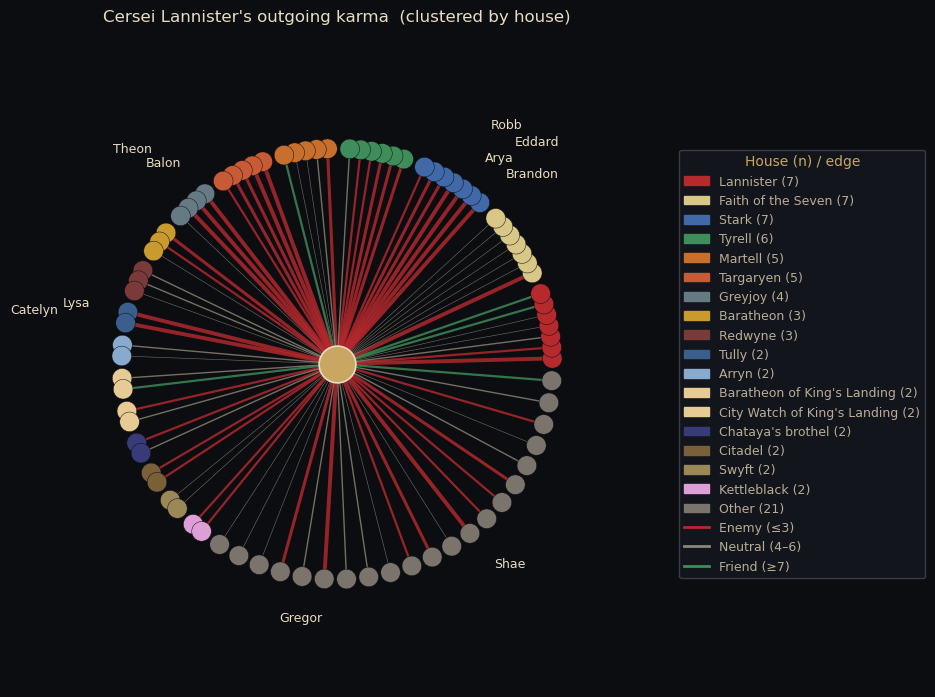

Saved website/figures/ego_networks/jon_snow.png


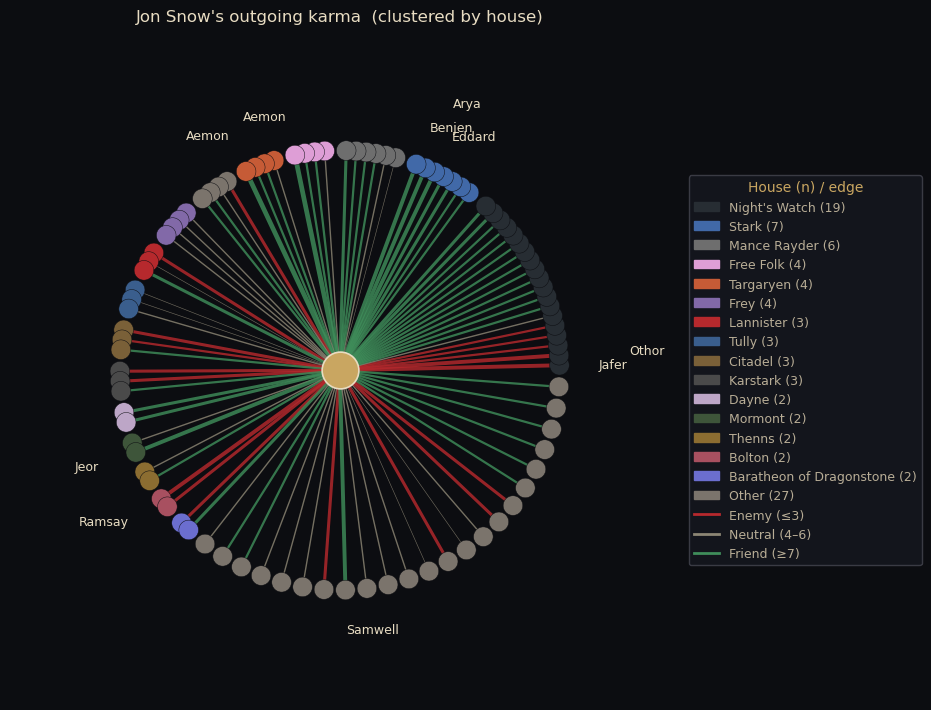

Saved website/figures/ego_networks/daenerys_targaryen.png


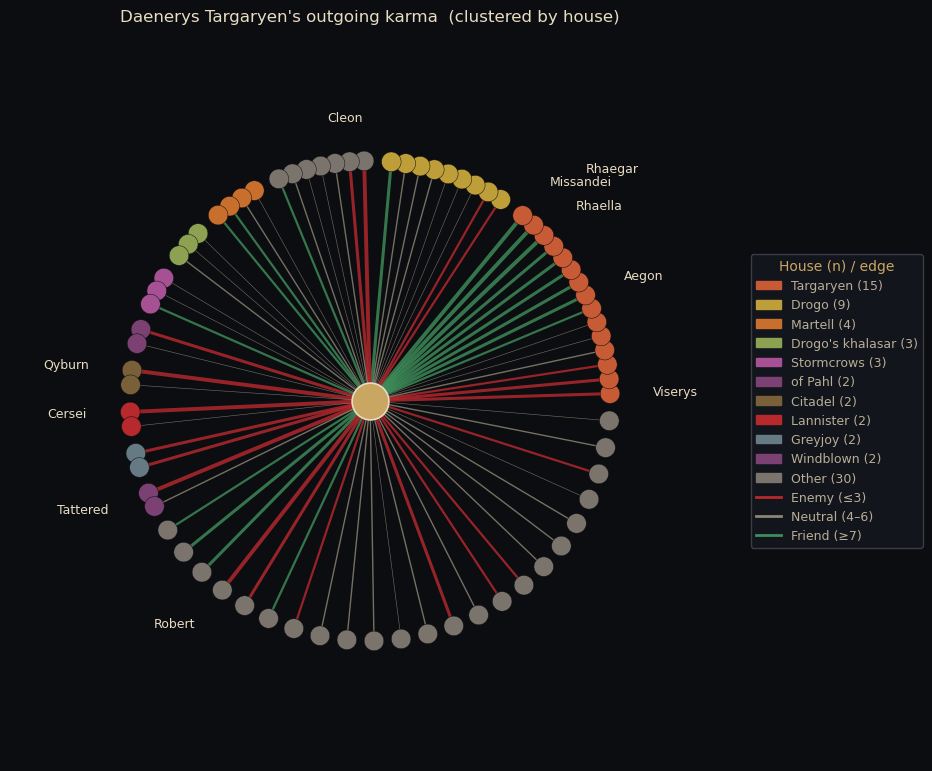

Saved website/figures/ego_networks/petyr_baelish.png


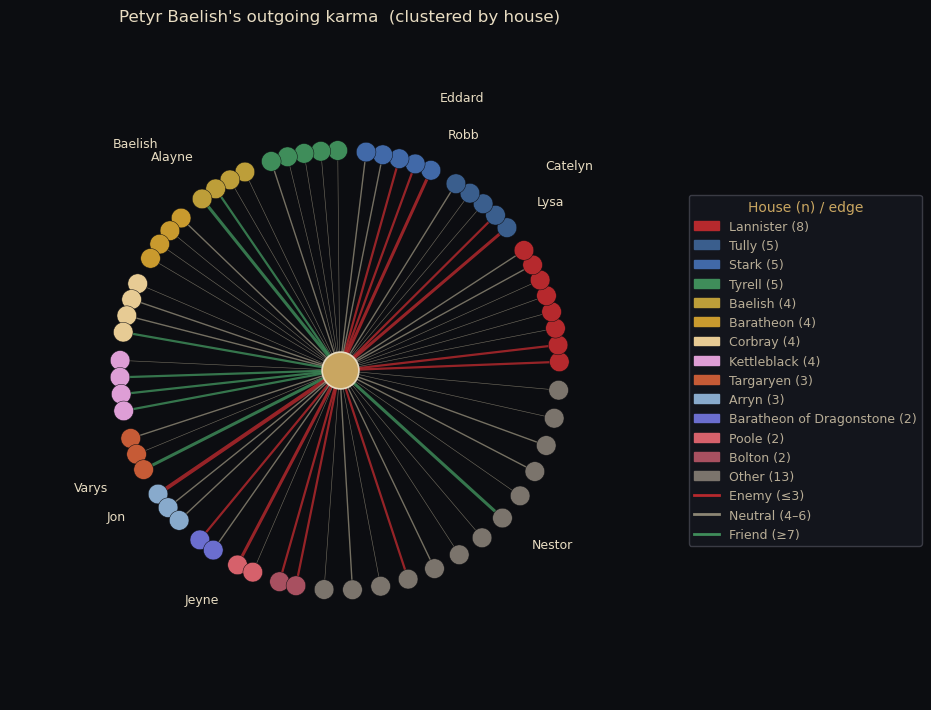

Saved website/figures/ego_networks/theon_greyjoy.png


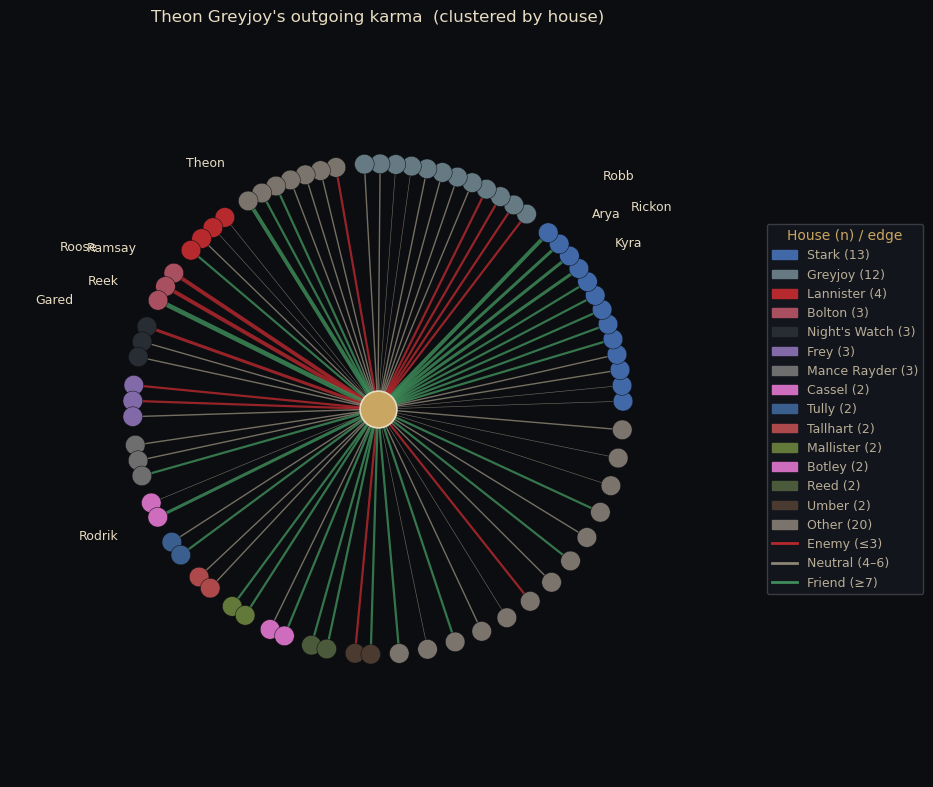

Saved website/figures/ego_networks/melisandre.png


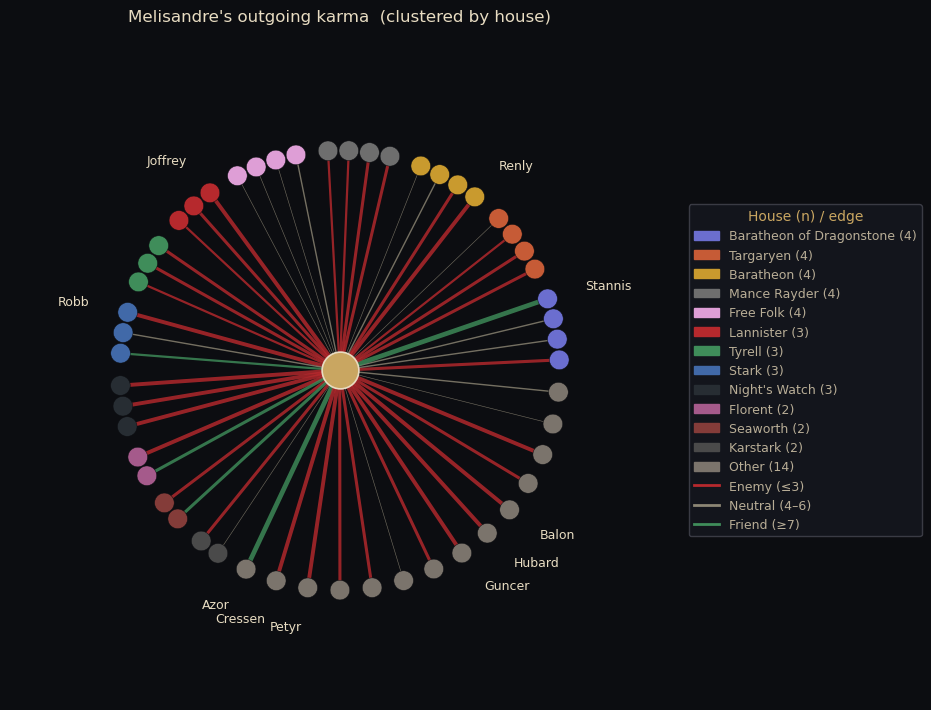

Saved website/figures/ego_networks/walder_frey.png


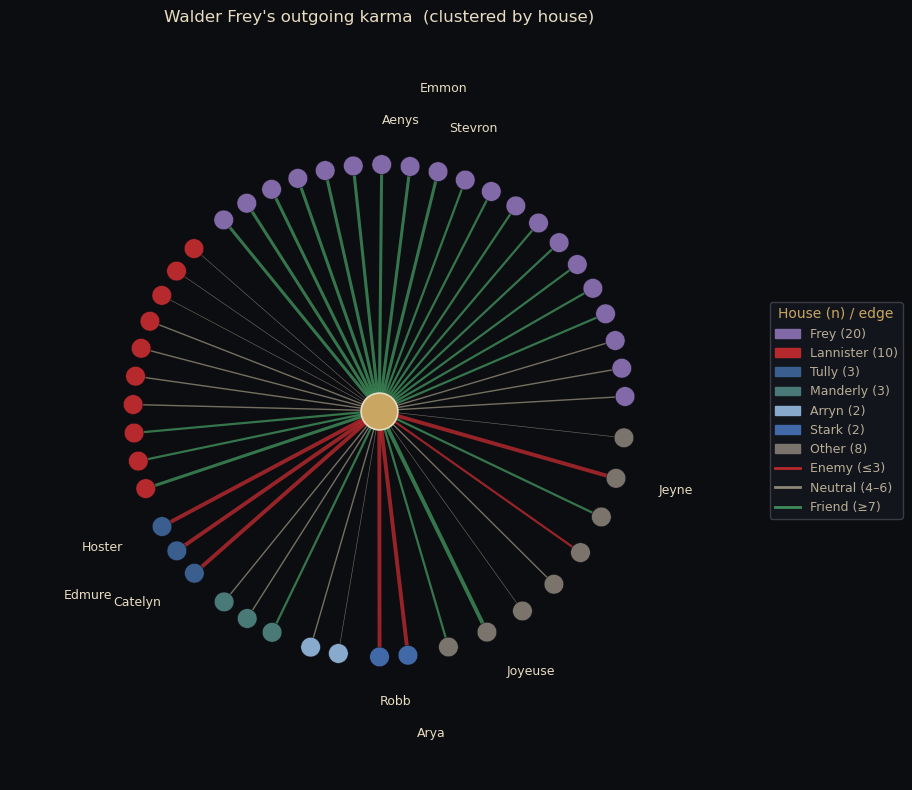

Saved website/figures/ego_networks/sandor_clegane.png


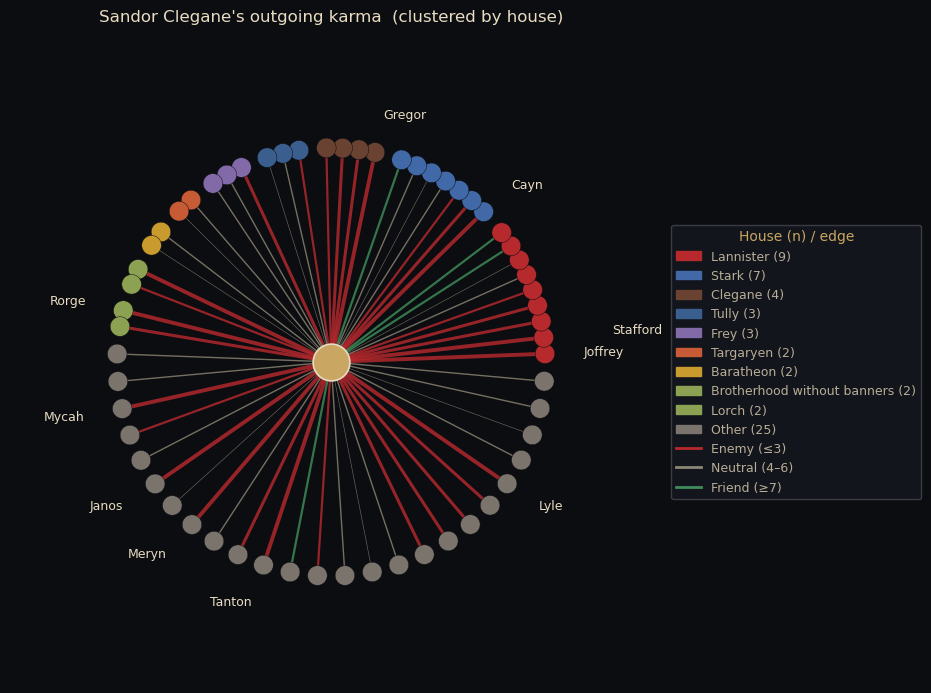

Saved website/figures/ego_networks/robb_stark.png


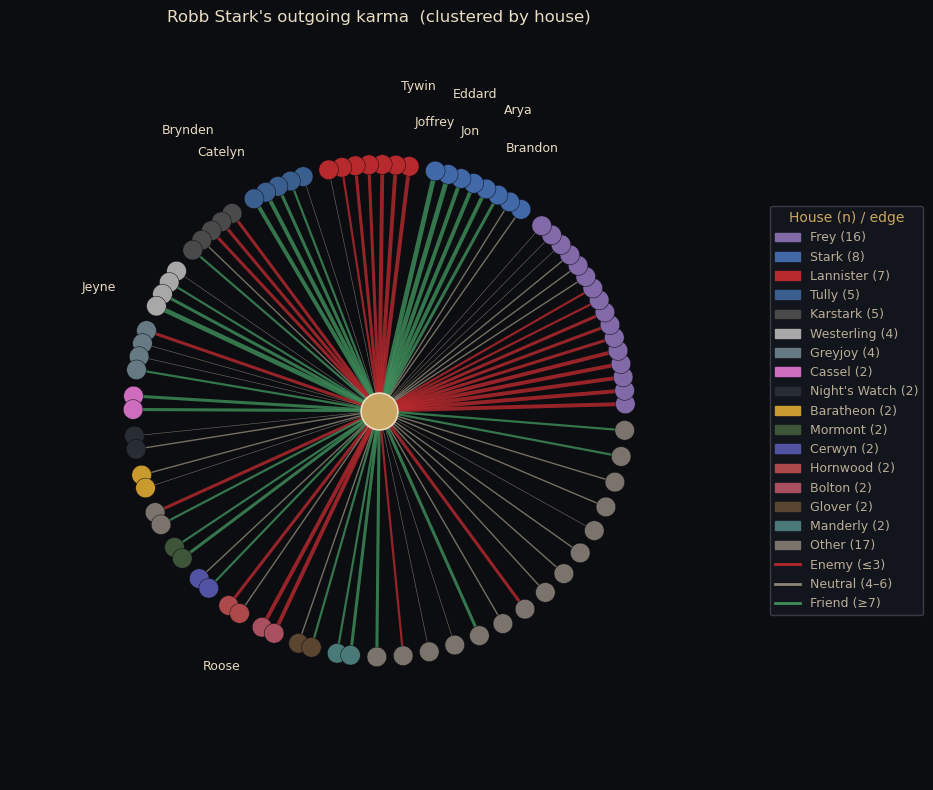

In [31]:
from collections import defaultdict

EGO_IDS = ['Tyrion_Lannister', 'Cersei_Lannister', 'Jon_Snow', 'Daenerys_Targaryen', 'Petyr_Baelish', 'Theon_Greyjoy', 'Melisandre', 'Walder_Frey', 'Sandor_Clegane', 'Robb_Stark']
TOP_LABELS = 10
HOUSE_LEGEND_MIN = 2
LABEL_RADIUS = 1.18
LABEL_RADIUS_OUTER = 1.32
LABEL_COLLISION_DEG = 7
GAP_DEG = 3
EGO_DIR = BASE_DIR / 'website' / 'figures' / 'ego_networks'
EGO_DIR.mkdir(parents=True, exist_ok=True)

# Website palette for ego-network PNGs.
EGO_BG = '#0c0d11'
EGO_SURFACE = '#14161d'
EGO_INK = '#e8dcc2'
EGO_MUTED = '#b8ad96'
EGO_GOLD = '#c9a661'
EGO_LINE = '#3d3e48'


for ego in EGO_IDS:
    fig, ax = plt.subplots(figsize=(9, 8), facecolor=EGO_BG)
    ax.set_facecolor(EGO_BG)

    if ego not in DG:
        ax.set_title(f'{ego}\n(not in graph)', color=EGO_INK); ax.set_axis_off(); plt.show(); continue
    out = list(DG.out_edges(ego, data=True))
    if not out:
        ax.set_title(f'{name_by_id.get(ego, ego)}\n(no outgoing edges)', color=EGO_INK); ax.set_axis_off(); plt.show(); continue

    nbhd_by_house = defaultdict(list)
    for _, v, d in out:
        h = primary_house.get(v, '') or '(no house)'
        nbhd_by_house[h].append((v, d['score']))

    houses_ordered = sorted(nbhd_by_house, key=lambda h: -len(nbhd_by_house[h]))
    for h in houses_ordered:
        nbhd_by_house[h].sort(key=lambda x: x[1])

    N_houses = len(houses_ordered)
    total_neighbors = sum(len(m) for m in nbhd_by_house.values())
    gap_angle = np.deg2rad(GAP_DEG)
    slot_step = (2 * np.pi - N_houses * gap_angle) / total_neighbors

    pos = {ego: (0.0, 0.0)}
    angle_by_node, node_house, score_by_node = {}, {}, {}

    cur = 0.0
    for h in houses_ordered:
        for v, s in nbhd_by_house[h]:
            theta = cur + slot_step / 2
            pos[v] = (np.cos(theta), np.sin(theta))
            angle_by_node[v] = theta
            node_house[v] = h
            score_by_node[v] = s
            cur += slot_step
        cur += gap_angle

    neighbors = [v for h in houses_ordered for v, _ in nbhd_by_house[h]]
    legend_houses = [h for h in houses_ordered if len(nbhd_by_house[h]) >= HOUSE_LEGEND_MIN and h != '(no house)']

    def color_for(v):
        h = node_house[v]
        return house_color_for(h) if h in legend_houses else OTHER_COLOR

    edgelist = [(ego, v) for v in neighbors]
    ecolors, ewidths = [], []
    for v in neighbors:
        s = score_by_node[v]
        ecolors.append(KARMA_RED if s <= 3 else KARMA_GREEN if s >= 7 else NEUTRAL)
        ewidths.append(0.4 + abs(s - 5) * 0.6)

    ego_sub = DG.edge_subgraph(edgelist).copy()
    nx.draw_networkx_edges(ego_sub, pos, edgelist=edgelist,
                           edge_color=ecolors, width=ewidths, alpha=0.82, arrows=False, ax=ax)
    nx.draw_networkx_nodes(ego_sub, pos, nodelist=[ego], node_color='#c9a661', node_size=700,
                           edgecolors=EGO_INK, linewidths=1.2, ax=ax)
    nx.draw_networkx_nodes(ego_sub, pos, nodelist=neighbors,
                           node_color=[color_for(v) for v in neighbors],
                           node_size=200, linewidths=0.35, edgecolors=EGO_BG, ax=ax)

    extreme_ids = [v for _, v, _ in sorted(out, key=lambda e: abs(e[2]['score'] - 5), reverse=True)[:TOP_LABELS]]
    extreme_ids.sort(key=lambda v: angle_by_node[v])
    prev_angle, prev_radius = None, None
    coll = np.deg2rad(LABEL_COLLISION_DEG)
    for v in extreme_ids:
        a = angle_by_node[v]
        if prev_angle is not None and (a - prev_angle) < coll:
            radius = LABEL_RADIUS_OUTER if prev_radius == LABEL_RADIUS else LABEL_RADIUS
        else:
            radius = LABEL_RADIUS
        x, y = radius * np.cos(a), radius * np.sin(a)
        ha = 'left' if np.cos(a) >= 0 else 'right'
        ax.text(x, y, name_by_id.get(v, v).split()[0], ha=ha, va='center', fontsize=9, color=EGO_INK)
        prev_angle, prev_radius = a, radius

    house_handles = [
        mpatches.Patch(color=house_color_for(h),
                       label=f"{h.replace('House_', '').replace('_', ' ')} ({len(nbhd_by_house[h])})")
        for h in legend_houses
    ]
    other_count = sum(len(nbhd_by_house[h]) for h in houses_ordered if h not in legend_houses)
    if other_count:
        house_handles.append(mpatches.Patch(color=OTHER_COLOR, label=f'Other ({other_count})'))

    edge_handles = [
        plt.Line2D([0], [0], color=KARMA_RED,   lw=2, label='Enemy (≤3)'),
        plt.Line2D([0], [0], color=NEUTRAL,     lw=2, label='Neutral (4–6)'),
        plt.Line2D([0], [0], color=KARMA_GREEN, lw=2, label='Friend (≥7)'),
    ]
    leg = ax.legend(handles=house_handles + edge_handles,
                    loc='center left', bbox_to_anchor=(1.02, 0.5),
                    fontsize=9, frameon=True, title='House (n) / edge',
                    facecolor=EGO_SURFACE, edgecolor=EGO_LINE, framealpha=0.94)
    leg.get_title().set_fontsize(10)
    leg.get_title().set_color(EGO_GOLD)
    for text in leg.get_texts():
        text.set_color(EGO_MUTED)

    ax.set_title(f"{name_by_id.get(ego, ego)}'s outgoing karma  (clustered by house)", color=EGO_INK, pad=14)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal'); ax.set_axis_off()
    plt.tight_layout()
    out = EGO_DIR / f"{ego.lower()}.png"
    fig.savefig(out, dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
    print(f'Saved {out.relative_to(BASE_DIR)}')
    plt.show()


---

## Exploratory plots not included

During development we also tried several broader karma views:

- **House-pair heatmap**: useful for checking whether LLM scores aggregated into sensible house-level patterns, but too dense for the website's story.
- **Karma asymmetry scatter**: useful for testing whether directed scores add information beyond undirected affiliation, but harder to explain quickly to a general reader.
- **House-level rankings**: useful for writing captions and checking outliers, but more diagnostic than visual storytelling.

Those experiments helped us decide that the website should focus on two clearer outputs: the global score distribution and character-level ego networks. The construction of `karma_edges_v3.csv` is documented in `llm.ipynb`; this notebook starts from that finished file and exports the figures used by the website.